Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

Directories

In [4]:
REPORT_DIR = "../../src/reports"
IMAGE_DIR = "../../src/reports/images"

Path(REPORT_DIR).mkdir(
    parents=True,
    exist_ok=True
)

Path(IMAGE_DIR).mkdir(
    parents=True,
    exist_ok=True
)

Load Historical Dataset

In [5]:
df = pd.read_parquet(
    "../../data/curated/environmental_master.parquet"
)

print(df.shape)

df.head()

(508116, 20)


,datetime,station_id,station_name,district,latitude,longitude,aqi,pm25,pm10,humidity,temperature,temperature_2m,relative_humidity_2m,dew_point_2m,precipitation,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m,wind_gusts_10m
0,2022-01-01 21:00:00,WB005,"East Calcutta Girls College, Lake Town",Kolkata,22.601583,88.404556,123,66.79,109.32,71.50,18.09,15.6,87,13.4,0.0,1018.4,48,7.6,315,11.2
1,2022-01-01 21:00:00,WB009,Leather Complex,Kolkata,22.495300,88.509293,193,87.98,173.04,72.72,18.48,16.2,81,13.0,0.0,1018.6,18,7.4,331,12.6
2,2022-01-01 21:00:00,WB015,Sarsuna College,Kolkata,22.481270,88.284554,185,85.59,194.13,73.95,18.51,16.8,78,12.9,0.0,1018.7,57,7.4,317,13.3
3,2022-01-01 22:00:00,WB005,"East Calcutta Girls College, Lake Town",Kolkata,22.601583,88.404556,145,73.56,156.15,75.74,17.73,15.4,88,13.5,0.0,1018.3,100,7.4,321,11.2
4,2022-01-01 22:00:00,WB009,Leather Complex,Kolkata,22.495300,88.509293,231,99.37,168.51,75.08,18.05,15.6,85,13.1,0.0,1018.4,74,7.1,330,11.2


In [6]:
df["datetime"] = pd.to_datetime(
    df["datetime"]
)

df = df.sort_values(
    "datetime"
)

df.reset_index(
    drop=True,
    inplace=True
)

## Feature Engineering

In [7]:
df["hour"] = df["datetime"].dt.hour

df["day_of_week"] = (
    df["datetime"]
    .dt.dayofweek
)

df["month"] = (
    df["datetime"]
    .dt.month
)

Season Feature

In [8]:
def get_season(month):

    if month in [3,4,5]:
        return 1

    elif month in [6,7,8,9]:
        return 2

    return 3

df["season"] = (
    df["month"]
    .apply(get_season)
)

Lag Features

In [9]:
df["lag_1"] = df["aqi"].shift(1)

df["lag_3"] = df["aqi"].shift(3)

df["lag_6"] = df["aqi"].shift(6)

df["lag_12"] = df["aqi"].shift(12)

df["lag_24"] = df["aqi"].shift(24)

Rolling Features

In [10]:
df["rolling_mean_6"] = (
    df["aqi"]
    .rolling(6)
    .mean()
)

df["rolling_mean_12"] = (
    df["aqi"]
    .rolling(12)
    .mean()
)

df["rolling_mean_24"] = (
    df["aqi"]
    .rolling(24)
    .mean()
)

In [11]:
df = df.dropna()

print(df.shape)

(508092, 32)


## Forecast Horizon Construction

In [12]:
forecast_hours = 24

df["target"] = (
    df["aqi"]
    .shift(-forecast_hours)
)

df = df.dropna()

print(df.shape)

(508068, 33)


## Feature Selection

In [13]:
features = [

    "pm25",
    "pm10",

    "temperature_2m",
    "dew_point_2m",

    "surface_pressure",

    "cloud_cover",

    "wind_speed_10m",
    "wind_gusts_10m",

    "hour",
    "month",
    "season",

    "lag_1",
    "lag_3",
    "lag_6",
    "lag_12",
    "lag_24",

    "rolling_mean_6",
    "rolling_mean_12",
    "rolling_mean_24"
]

X = df[features]

y = df["target"]

## Time-Based Train / Validation / Test Split

In [14]:
train = df[
    df["datetime"] < "2025-01-01"
]

validation = df[
    (df["datetime"] >= "2025-01-01")
    &
    (df["datetime"] < "2026-01-01")
]

test = df[
    df["datetime"] >= "2026-01-01"
]

In [15]:
X_train = train[features]
y_train = train["target"]

X_val = validation[features]
y_val = validation["target"]

X_test = test[features]
y_test = test["target"]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(308106, 19)
(143755, 19)
(56207, 19)


## Evaluation Function

In [16]:
def evaluate_model(
    model_name,
    y_true,
    y_pred
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    mape = (
        np.mean(
            np.abs(
                (y_true - y_pred)
                / y_true
            )
        )
        * 100
    )

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape
    }

## Model 1 - Linear Regression

In [17]:
lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(
    X_test
)

lr_metrics = evaluate_model(
    "Linear Regression",
    y_test,
    lr_pred
)

lr_metrics

{'Model': 'Linear Regression',
 'MAE': 23.030749296200057,
 'RMSE': np.float64(34.97029667322911),
 'R2': 0.4637972129033927,
 'MAPE': np.float64(29.549104600555275)}

## Model 2 - Random Forest

In [18]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

rf_metrics = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

rf_metrics

{'Model': 'Random Forest',
 'MAE': 24.617680449054387,
 'RMSE': np.float64(35.79472455353713),
 'R2': 0.4382171419278733,
 'MAPE': np.float64(33.2264597384574)}

## Model 3 - XGBoost

In [19]:
xgb = XGBRegressor(

    n_estimators=300,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

xgb_pred = xgb.predict(
    X_test
)

xgb_metrics = evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred
)

xgb_metrics

{'Model': 'XGBoost',
 'MAE': 23.620863664478343,
 'RMSE': np.float64(34.91201353672127),
 'R2': 0.46558304491124614,
 'MAPE': np.float64(31.433222180663222)}

## Model Comparison

In [21]:
results = pd.DataFrame([

    lr_metrics,

    rf_metrics,

    xgb_metrics

])

results

,Model,MAE,RMSE,R2,MAPE
0,Linear Regression,23.030749,34.970297,0.463797,29.549105
1,Random Forest,24.617680,35.794725,0.438217,33.226460
2,XGBoost,23.620864,34.912014,0.465583,31.433222


In [22]:
results.to_csv(
    f"{REPORT_DIR}/forecasting_summary.csv",
    index=False
)

results

,Model,MAE,RMSE,R2,MAPE
0,Linear Regression,23.030749,34.970297,0.463797,29.549105
1,Random Forest,24.617680,35.794725,0.438217,33.226460
2,XGBoost,23.620864,34.912014,0.465583,31.433222


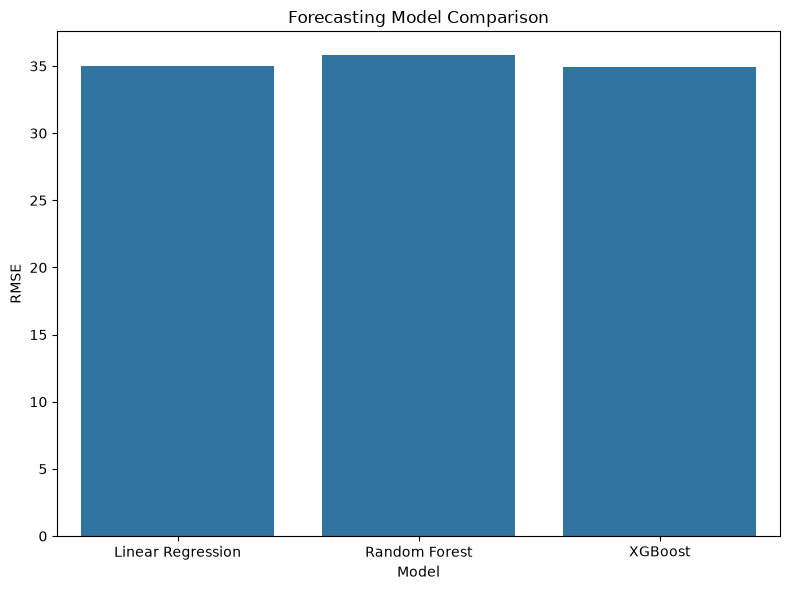

In [23]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=results,
    x="Model",
    y="RMSE"
)

plt.title(
    "Forecasting Model Comparison"
)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/model_comparison.png",
    dpi=300
)

plt.show()

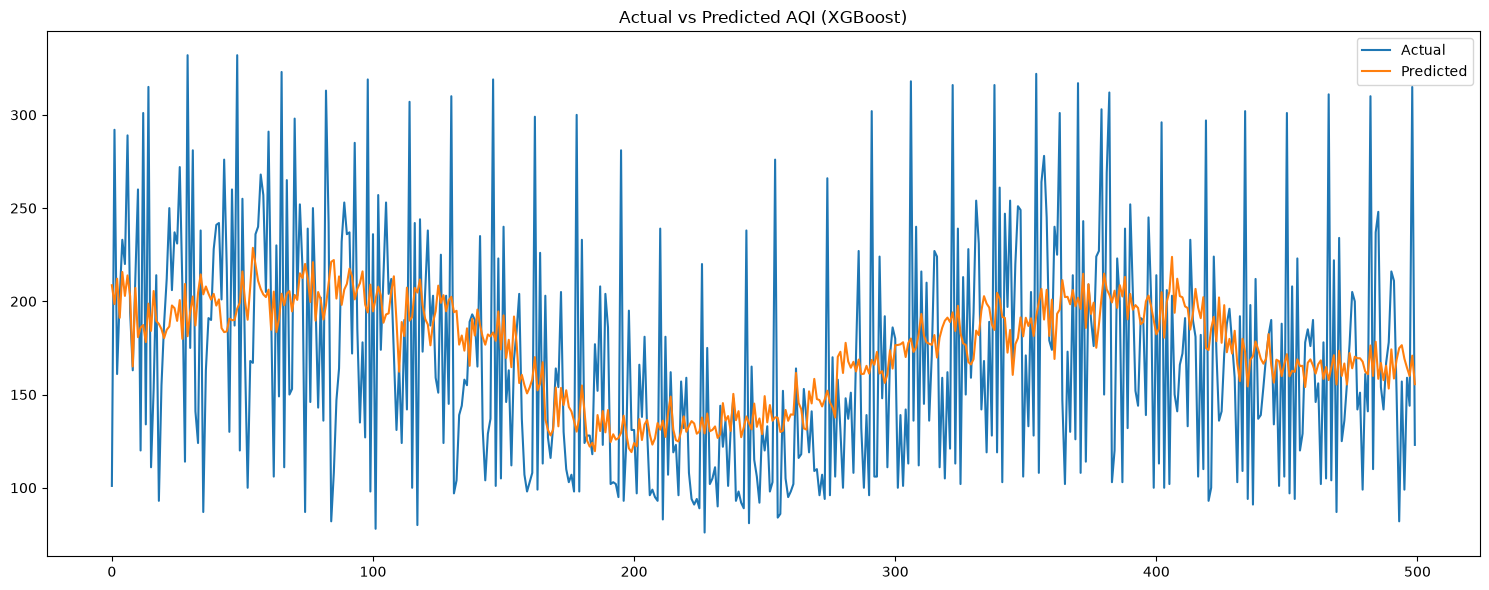

In [24]:
comparison = pd.DataFrame({

    "Actual":
        y_test.values[:500],

    "Predicted":
        xgb_pred[:500]
})

plt.figure(figsize=(15,6))

plt.plot(
    comparison["Actual"],
    label="Actual"
)

plt.plot(
    comparison["Predicted"],
    label="Predicted"
)

plt.legend()

plt.title(
    "Actual vs Predicted AQI (XGBoost)"
)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/actual_vs_predicted_xgb.png",
    dpi=300
)

plt.show()